## Machine Learning Essentials Exercise 1
### 1 Exploring the Data

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
Images size: (1797, 8, 8)


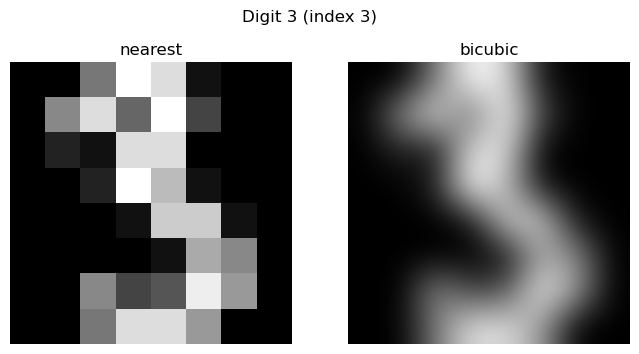

In [40]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# load the dataset
digits = load_digits()

print(digits.keys())

# extracts data, images, target, target_names
data = digits['data']
images = digits['images']
target = digits['target']
target_names = digits['target_names']

# size of the images
images_size = images.shape

print(f'Images size: {images_size}')

# visualize one image of a 3
# find an idx where target == 3
digit = 3
idx = np.where(target == digit)[0][0] # returns the first index where target is matched
img = images[idx]

# check if img is a 2-D array
assert 2 == len(img.shape), 'The image is not a 2-D array'

# plot with the two interpolation methods('nearest' and 'bicubic')
plt.figure(figsize=(8, 4))
plt.gray()

plt.subplot(1, 2, 1)
plt.imshow(img, interpolation='nearest')
plt.title('nearest')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img, interpolation='bicubic')
plt.title('bicubic')
plt.axis('off')

plt.suptitle(f'Digit {digit} (index {idx})')
plt.show()

# filter the dataset for '3' and '9'
mask = np.isin(target, [3, 9])

data_39 = data[mask]
images_39 = images[mask]
target_39 = target[mask]

# split the filtered dataset into training set and testing set
X_train, X_test, y_train, y_test, images_train, images_test = train_test_split(
    data_39,
    target_39,
    images_39,
    test_size=0.4,
    random_state=0,
    stratify=target_39
)


### 2 Hand-crafted classifier

#### 2.1 Feature Construction

In [52]:
def features2d(X_train, y_train):
    # select the images that are 3 and 9
    mask3 = np.isin(y_train, [3])
    mask9 = np.isin(y_train, [9])

    img3s = X_train[mask3]
    img9s = X_train[mask9]

    if len(img3s) == 0 or len(img9s) == 0:
        raise ValueError("Training split must contain both classes 3 and 9.")

    # find the average of each pixel across all images
    avg_img3s = img3s.mean(axis=0)
    avg_img9s = img9s.mean(axis=0)

    # calculate the difference
    diff = np.abs(avg_img3s - avg_img9s)

    # find the two pixels position (indices) with biggest difference
    best_pixels_idx = np.argsort(diff)[::-1] # sort from biggest to smallest
    best_idx1 = best_pixels_idx[0]
    best_idx2 = best_pixels_idx[1]

    f1 = X_train[:, best_idx1]
    f2 = X_train[:, best_idx2]

    features = np.column_stack([f1, f2])

    # visualize the average images and their difference

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(avg_img3s.reshape(8, 8), cmap='gray')
    axes[0].set_title("Average 3")

    axes[1].imshow(avg_img9s.reshape(8, 8), cmap='gray')
    axes[1].set_title("Average 9")

    axes[2].imshow(diff.reshape(8, 8), cmap='hot')
    axes[2].set_title("Difference (bright = most useful)")

    plt.show()
    
    return features

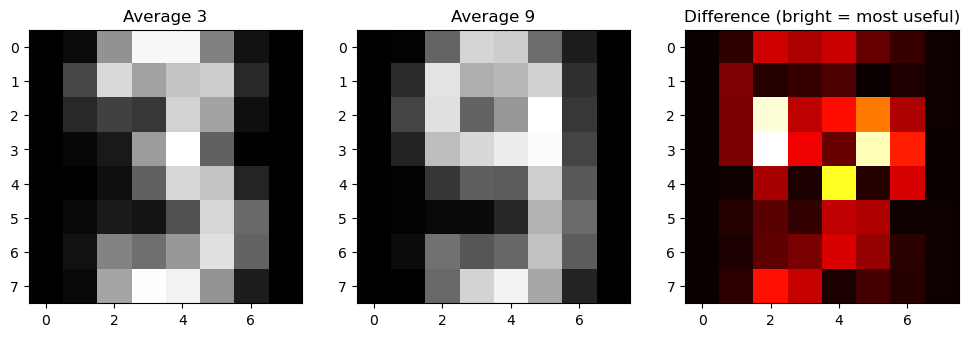

In [53]:
features = features2d(X_train, y_train)       # returns shape (n_train, 2) 

#### 2.2 Scatterplot

#### 2.3 Decision rule

#### 2.4 Visualize the decision regions

### 3 LDA
#### 3.1 Implement LDA training

#### 3.2 Implement LDA prediction

#### 3.3 Visualization

#### 3.4 Quantitative performance evaluation

### 4 SVM